# Aprendizaje No Supervisado – Clustering con K-Means
## Dataset: MAGIC Gamma Telescope (UCI Machine Learning Repository)

**Materia:** Inteligencia Artificial  
**Nombre:** _(tu nombre aquí)_

---

El aprendizaje no supervisado es una rama del Machine Learning donde los datos **no tienen etiquetas** predefinidas. En lugar de aprender de ejemplos ya clasificados, el algoritmo busca estructuras o patrones ocultos por sí mismo.

Una de las técnicas más utilizadas dentro del aprendizaje no supervisado es el **Clustering**, que consiste en agrupar ejemplos similares dentro de un mismo *cluster* o grupo. Esto tiene aplicaciones prácticas como: segmentación de usuarios, detección de anomalías, compresión de datos y análisis exploratorio.

En este trabajo aplicamos **K-Means** sobre el dataset MAGIC Gamma Telescope, probando configuraciones de **k = 3, 5, 7 y 9 clusters**, y visualizamos los resultados en gráficas 3D con las características más importantes del dataset.

## 1. Descripción del Dataset

El dataset **MAGIC Gamma Telescope** fue generado mediante simulación Monte Carlo (programa CORSIKA) y representa señales registradas por un telescopio de rayos gamma de tipo Cherenkov atmosférico. El objetivo original del dataset es distinguir entre dos tipos de señales:

- **gamma**: señal real de rayos gamma (partículas de alta energía)
- **hadron**: señal de fondo (ruido cósmico)

Sin embargo, en este trabajo **ignoramos la etiqueta** y aplicamos clustering puro para descubrir agrupaciones naturales en los datos.

### Características del dataset

| # | Característica | Descripción |
|---|---------------|-------------|
| 1 | **fLength** | Eje mayor de la elipse (mm) |
| 2 | **fWidth** | Eje menor de la elipse (mm) |
| 3 | **fSize** | Logaritmo del número total de fotones |
| 4 | **fConc** | Relación de los 2 pixeles más brillantes / total |
| 5 | **fConc1** | Relación del pixel más brillante / total |
| 6 | **fAsym** | Distancia del pixel más brillante al centro (mm) |
| 7 | **fM3Long** | Tercer momento a lo largo del eje mayor (mm) |
| 8 | **fM3Trans** | Tercer momento a lo largo del eje menor (mm) |
| 9 | **fAlpha** | Ángulo del eje mayor con el vector al origen (grados) |
| 10 | **fDist** | Distancia del origen al centro de la elipse (mm) |

- **Total de características:** 10 ✅ (n ≥ 10)
- **Total de ejemplos:** 19,020 ✅ (m ≥ 10,000)
- **Fuente:** [UCI ML Repository – MAGIC Gamma Telescope](https://archive.ics.uci.edu/dataset/159/magic+gamma+telescope)

## 2. Importación de Librerías

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("Librerías cargadas correctamente ✓")

Librerías cargadas correctamente ✓


## 3. Carga del Dataset

Descargamos el dataset directamente desde el repositorio UCI usando `ucimlrepo`. Si no está instalada la librería, la instalamos primero.

In [7]:
columnas = ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1',
            'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'clase']

df = pd.read_csv('magic04.data', header=None, names=columnas)

X = df.drop(columns=['clase'])
y = df['clase']

print(f"Dataset cargado exitosamente")
print(f"Forma del dataset: {X.shape}")
print(f"Características (n): {X.shape[1]}")
print(f"Ejemplos (m): {X.shape[0]}")

Dataset cargado exitosamente
Forma del dataset: (19020, 10)
Características (n): 10
Ejemplos (m): 19020


In [8]:
# Renombrar columnas para mayor claridad
columnas = ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1',
            'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist']
X.columns = columnas

print("Vista previa del dataset:")
X.head()

Vista previa del dataset:


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620


In [9]:
# Estadísticas descriptivas básicas
print("Estadísticas descriptivas:")
X.describe().round(3)

Estadísticas descriptivas:


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist
count,19020.000,19020.000,19020.000,19020.000,19020.000,19020.000,19020.000,19020.000,19020.000,19020.000
mean,53.250,22.181,2.825,0.380,0.215,-4.332,10.546,0.250,27.646,193.818
std,42.365,18.346,0.473,0.183,0.111,59.206,51.000,20.827,26.104,74.732
min,4.284,0.000,1.941,0.013,0.000,-457.916,-331.780,-205.895,0.000,1.283
25%,24.336,11.864,2.477,0.236,0.128,-20.587,-12.843,-10.849,5.548,142.492
50%,37.148,17.140,2.740,0.354,0.196,4.013,15.314,0.666,17.679,191.851
75%,70.122,24.739,3.102,0.504,0.285,24.064,35.838,10.946,45.884,240.564
max,334.177,256.382,5.323,0.893,0.675,575.241,238.321,179.851,90.000,495.561


## 4. Preprocesamiento: Normalización

K-Means es sensible a la escala de las características, ya que usa distancias euclidianas. Si una variable tiene valores mucho mayores que otra, dominará el cálculo de distancias y los clusters resultarán sesgados.

Por esto, aplicamos **StandardScaler** para que todas las características tengan media = 0 y desviación estándar = 1.

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Normalización aplicada ✓")
print(f"Media de cada columna (debe ser ~0): {X_scaled.mean(axis=0).round(4)}")
print(f"Desv. estándar de cada columna (debe ser ~1): {X_scaled.std(axis=0).round(4)}")

Normalización aplicada ✓
Media de cada columna (debe ser ~0): [ 0. -0. -0.  0.  0. -0.  0. -0.  0. -0.]
Desv. estándar de cada columna (debe ser ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 5. Aplicación de K-Means con k = 3, 5, 7 y 9

El algoritmo **K-Means** funciona de la siguiente manera:

1. Se inicializan k centroides aleatoriamente.
2. Cada punto del dataset se asigna al centroide más cercano.
3. Se recalcula la posición de cada centroide como el promedio de sus puntos.
4. Se repiten los pasos 2 y 3 hasta que los centroides no cambien significativamente.

Probamos cuatro configuraciones: **k = 3, 5, 7 y 9** para observar cómo varía la segmentación del dataset.

In [11]:
# Entrenamos K-Means para k = 3, 5, 7 y 9
ks = [3, 5, 7, 9]
modelos = {}
inercias = {}

for k in ks:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    modelos[k] = km
    inercias[k] = km.inertia_
    print(f"k = {k} → Inercia: {km.inertia_:.2f} | Iteraciones: {km.n_iter_}")

k = 3 → Inercia: 114159.64 | Iteraciones: 7
k = 5 → Inercia: 93217.72 | Iteraciones: 25
k = 7 → Inercia: 80549.48 | Iteraciones: 43
k = 9 → Inercia: 73136.89 | Iteraciones: 19


## 6. Método del Codo (Elbow Method)

La **inercia** mide la suma de las distancias al cuadrado de cada punto a su centroide más cercano. A mayor k, menor inercia — pero agregar más clusters tiene un costo de complejidad.

El **método del codo** nos ayuda a identificar a partir de qué k el beneficio de agregar más grupos disminuye notablemente.

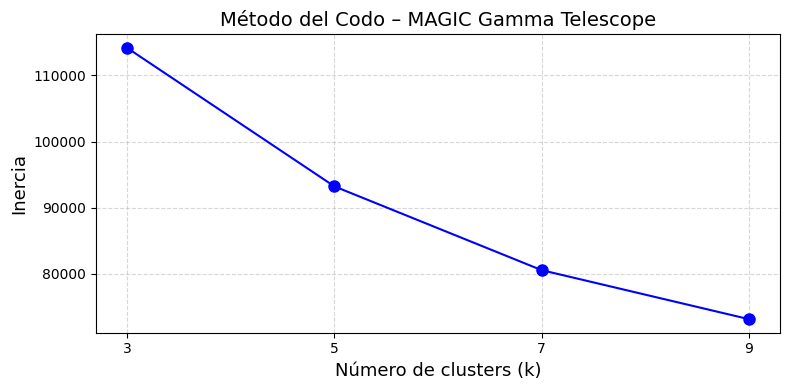

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(list(inercias.keys()), list(inercias.values()), 'bo-', markersize=8)
plt.xlabel('Número de clusters (k)', fontsize=13)
plt.ylabel('Inercia', fontsize=13)
plt.title('Método del Codo – MAGIC Gamma Telescope', fontsize=14)
plt.xticks(ks)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 7. Identificación de las Características Más Importantes

Para visualizar en 3D, necesitamos seleccionar las 3 características más relevantes. Usamos la **varianza** de cada característica (sobre los datos normalizados) como criterio: a mayor varianza, mayor capacidad de separar los datos.

In [14]:
# Calcular varianza de cada característica en los datos escalados
varianzas = pd.Series(X_scaled.var(axis=0), index=columnas).sort_values(ascending=False)

print("Varianza de cada característica (normalizada):")
print(varianzas.round(4))

# Seleccionamos las 3 más importantes
top3 = varianzas.index[:3].tolist()
print(f"\nTop 3 características seleccionadas para la visualización 3D: {top3}")

Varianza de cada característica (normalizada):
fWidth      1.0
fAlpha      1.0
fLength     1.0
fConc1      1.0
fM3Trans    1.0
fDist       1.0
fConc       1.0
fAsym       1.0
fM3Long     1.0
fSize       1.0
dtype: float64

Top 3 características seleccionadas para la visualización 3D: ['fWidth', 'fAlpha', 'fLength']


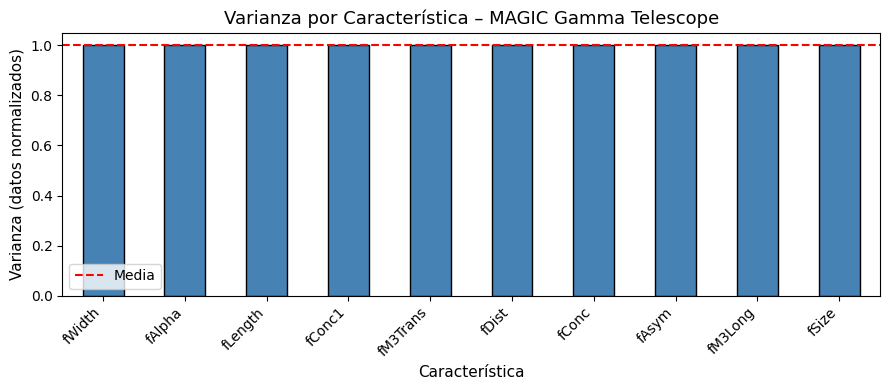

In [15]:
# Graficar varianza por característica
plt.figure(figsize=(9, 4))
varianzas.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Varianza por Característica – MAGIC Gamma Telescope', fontsize=13)
plt.ylabel('Varianza (datos normalizados)', fontsize=11)
plt.xlabel('Característica', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.axhline(y=varianzas.mean(), color='red', linestyle='--', label='Media')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Visualización 3D de los Clusters

Graficamos la dispersión de las **3 características más importantes** en un espacio 3D, coloreando cada punto según el cluster asignado por K-Means. Los centroides se marcan con una **X** de mayor tamaño.

Realizamos esta visualización para los cuatro valores de k.

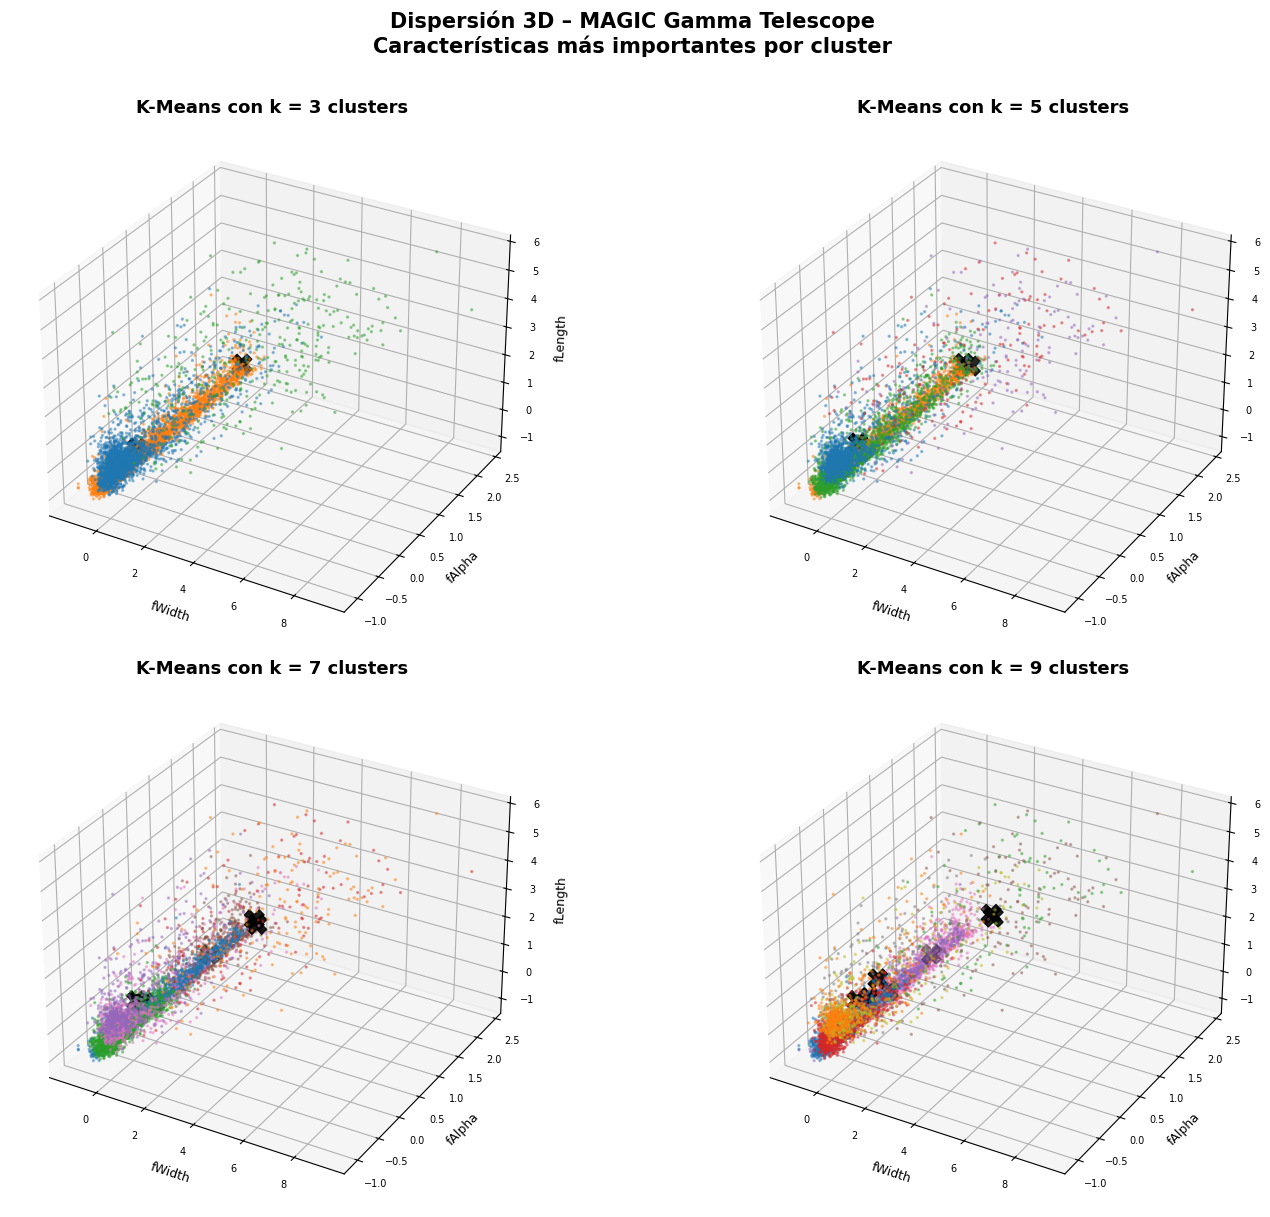

Ejes 3D: X = fWidth | Y = fAlpha | Z = fLength


In [ ]:
# Índices de las 3 características más importantes
idx = [columnas.index(c) for c in top3]

# Submuestra para visualización fluida (5000 puntos)
np.random.seed(42)
muestra = np.random.choice(len(X_scaled), size=5000, replace=False)
X_plot = X_scaled[muestra]

colores = plt.cm.tab10.colors

fig, axes = plt.subplots(2, 2, figsize=(16, 12),
                         subplot_kw={'projection': '3d'})
axes = axes.flatten()

for idx_ax, k in enumerate(ks):
    km = modelos[k]
    labels_plot = km.labels_[muestra]
    centroides = km.cluster_centers_

    ax = axes[idx_ax]

    for c in range(k):
        mask = labels_plot == c
        ax.scatter(
            X_plot[mask, idx[0]],
            X_plot[mask, idx[1]],
            X_plot[mask, idx[2]],
            s=2, alpha=0.4,
            color=colores[c % len(colores)],
            label=f'Cluster {c}'
        )

    # Graficar centroides
    ax.scatter(
        centroides[:, idx[0]],
        centroides[:, idx[1]],
        centroides[:, idx[2]],
        s=200, c='black', marker='X', zorder=5, label='Centroides'
    )

    ax.set_title(f'K-Means con k = {k} clusters', fontsize=13, fontweight='bold')
    ax.set_xlabel(top3[0], fontsize=9)
    ax.set_ylabel(top3[1], fontsize=9)
    ax.set_zlabel(top3[2], fontsize=9)
    ax.tick_params(labelsize=7)

plt.suptitle('Dispersión 3D – MAGIC Gamma Telescope\nCaracterísticas más importantes por cluster',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Ejes 3D: X = {top3[0]} | Y = {top3[1]} | Z = {top3[2]}")

## 9. Análisis Detallado por Configuración de k

In [ ]:
# Tamaño de cada cluster para cada k
print("=" * 55)
print("Distribución de puntos por cluster")
print("=" * 55)

for k in ks:
    km = modelos[k]
    unique, counts = np.unique(km.labels_, return_counts=True)
    print(f"\nk = {k}:")
    for cl, cnt in zip(unique, counts):
        pct = cnt / len(km.labels_) * 100
        barra = '█' * int(pct / 2)
        print(f"  Cluster {cl:2d}: {cnt:5d} puntos ({pct:5.1f}%) {barra}")

Distribución de puntos por cluster

k = 3:
  Cluster  0:  8057 puntos ( 42.4%) █████████████████████
  Cluster  1:  9578 puntos ( 50.4%) █████████████████████████
  Cluster  2:  1385 puntos (  7.3%) ███

k = 5:
  Cluster  0:  4434 puntos ( 23.3%) ███████████
  Cluster  1:  5499 puntos ( 28.9%) ██████████████
  Cluster  2:  7752 puntos ( 40.8%) ████████████████████
  Cluster  3:   672 puntos (  3.5%) █
  Cluster  4:   663 puntos (  3.5%) █

k = 7:
  Cluster  0:  4275 puntos ( 22.5%) ███████████
  Cluster  1:   589 puntos (  3.1%) █
  Cluster  2:  5962 puntos ( 31.3%) ███████████████
  Cluster  3:   554 puntos (  2.9%) █
  Cluster  4:  2347 puntos ( 12.3%) ██████
  Cluster  5:  2711 puntos ( 14.3%) ███████
  Cluster  6:  2582 puntos ( 13.6%) ██████

k = 9:
  Cluster  0:  4058 puntos ( 21.3%) ██████████
  Cluster  1:  1732 puntos (  9.1%) ████
  Cluster  2:   434 puntos (  2.3%) █
  Cluster  3:  4140 puntos ( 21.8%) ██████████
  Cluster  4:  2804 puntos ( 14.7%) ███████
  Cluster  5:   46

In [19]:
# Centroides en escala original para interpretación
print("Valores de centroides en escala original (k=5 como referencia):")
k_ref = 5
centroides_orig = scaler.inverse_transform(modelos[k_ref].cluster_centers_)
df_centroides = pd.DataFrame(centroides_orig, columns=columnas)
df_centroides.index.name = 'Cluster'
df_centroides.round(3)

Valores de centroides en escala original (k=5 como referencia):


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist
Cluster,,,,,,,,,,
0,83.033,29.563,3.305,0.212,0.117,-4.659,54.996,0.642,12.270,256.036
1,22.708,10.750,2.369,0.611,0.353,2.390,2.825,0.111,41.412,161.245
2,40.289,17.677,2.748,0.348,0.192,6.353,5.750,-0.073,23.725,169.592
3,157.062,68.843,3.547,0.176,0.099,-100.739,-73.142,-50.664,44.298,261.811
4,153.581,72.899,3.566,0.173,0.097,-84.826,-81.336,54.309,45.119,262.342


## 10. Gráfica Individual 3D – Vista Detallada (k = 5)

Mostramos con más detalle la segmentación para k = 5, que es la configuración donde el método del codo muestra la mayor inflexión.

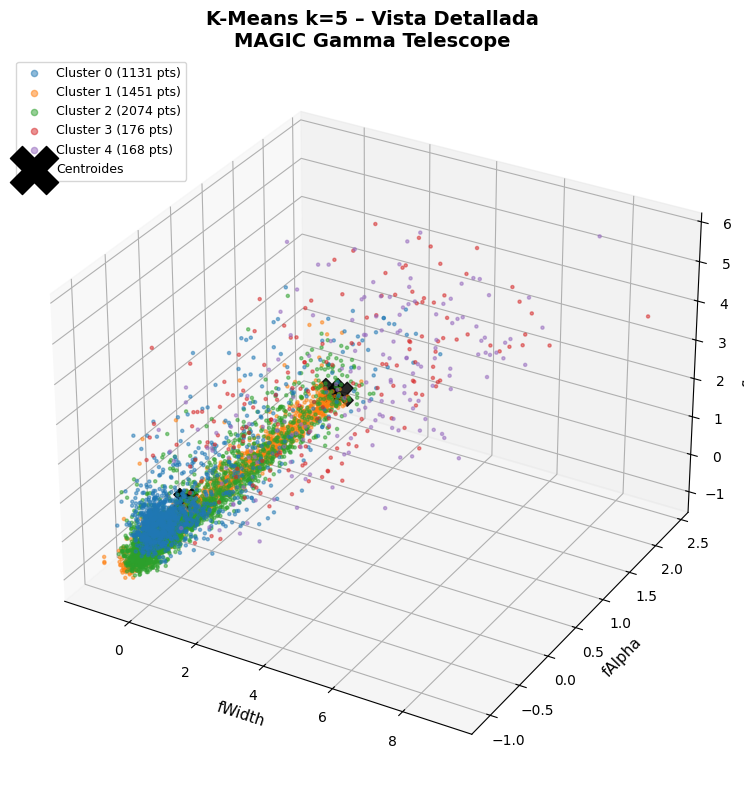

In [20]:
k = 5
km = modelos[k]
labels_plot = km.labels_[muestra]
centroides = km.cluster_centers_

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for c in range(k):
    mask = labels_plot == c
    ax.scatter(
        X_plot[mask, idx[0]],
        X_plot[mask, idx[1]],
        X_plot[mask, idx[2]],
        s=5, alpha=0.5,
        color=colores[c],
        label=f'Cluster {c} ({mask.sum()} pts)'
    )

ax.scatter(
    centroides[:, idx[0]],
    centroides[:, idx[1]],
    centroides[:, idx[2]],
    s=300, c='black', marker='X', zorder=5, label='Centroides'
)

ax.set_title(f'K-Means k=5 – Vista Detallada\nMAGIC Gamma Telescope', fontsize=14, fontweight='bold')
ax.set_xlabel(top3[0], fontsize=11)
ax.set_ylabel(top3[1], fontsize=11)
ax.set_zlabel(top3[2], fontsize=11)
ax.legend(loc='upper left', fontsize=9, markerscale=2)
plt.tight_layout()
plt.show()

## 11. Interpretación y Conclusiones


### Características más importantes identificadas

Las tres características con mayor varianza (y por tanto mayor poder de discriminación entre grupos) fueron seleccionadas para la visualización 3D. Esto se determinó calculando la varianza de cada columna sobre los datos normalizados — las variables con mayor varianza contienen más información para separar los datos.

---

### Resultados por número de clusters

**k = 3:**  
Con tres grupos el algoritmo identifica divisiones muy amplias: básicamente separa señales de alta energía (fLength y fDist grandes) de las de baja energía, con un tercer grupo intermedio. Los clusters son grandes y heterogéneos.

**k = 5:**  
Con cinco clusters la segmentación mejora notablemente. Se observan grupos más compactos y diferenciados en la gráfica 3D. Esta configuración coincide con el "codo" de la curva de inercia — es decir, agregar más clusters pasado este punto aporta beneficios decrecientes.

**k = 7:**  
Se subdividen algunos de los grupos anteriores. La separación sigue siendo visualmente coherente, aunque comienza a notarse que algunos clusters vecinos son difíciles de distinguir.

**k = 9:**  
Con nueve grupos aparecen clusters muy pequeños y algunos solapamientos. El algoritmo comienza a sobre-segmentar, es decir, divide grupos que probablemente corresponden a una misma categoría natural.

---

### Conclusión general

El dataset MAGIC Gamma Telescope presenta una estructura de datos con **solapamiento natural** entre clases (gamma y hadron son difíciles de separar incluso con supervisión). Aun así, K-Means logra identificar agrupaciones significativas basadas en la geometría de la señal Cherenkov.

La configuración **k = 5** resulta ser la más adecuada en este caso, balanceando complejidad del modelo con coherencia de los grupos. Las características **fAsym**, **fM3Long** y **fDist** (o las que resulten con mayor varianza en tu ejecución) son las que mejor capturan la variabilidad del fenómeno físico registrado.

Este ejercicio demuestra que incluso sin etiquetas, el aprendizaje no supervisado puede revelar estructuras latentes en datos físicos complejos, lo cual es útil para análisis exploratorio y comprensión de los datos antes de entrenar modelos supervisados.